# Seviye 2 - Arac x Sistem Q3 Tahmini (H Formulu + Tamir Etkililik Carpan)

**Tarih:** 2026-05-12 (V3 - Tamir analizi eklendi)
**Amac:** V6.1 modelinden gelen arac bazli genel risk + sistem bazli tahmin + TAMIR BAŞARISI analizi.

## V3 YENI: Tamir Etkililik Carpan

V6.1 modeli "kac ariza yapildi" bilgisi var ama "tamir basarili miydi" yok.
Bu V3'te Q1 vs Q2 sistem-bazli karsilastirma ile tamir durumu cikarilir:

| Durum | Tamir Carpan | Yorum |
|---|---|---|
| Q1'de var, Q2'de YOK | 0.5x | Tamir basarili, Q3'de dususuk |
| Q1+Q2 var, son 30 gun YOK | 0.8x | Azalan, kismen tamir |
| Q1+Q2 var, son 30 gun VAR | 1.3x | KRONIK, kotulesen |
| Q1 yok, Q2 var | 1.2x | YENI problem |
| Stabil | 1.0x | Degisim yok |

**Leakage yok cunku:** Q1 ve Q2 ikisi de "inference zamaninda gecmis veri". Q3 tahmini icin geleceğe ait bilgi kullanilmiyor. V6.1 modelinin train'i etkilenmiyor (Cozum B).

## H + Tamir Formulu (final)

```
P(arac X, Q3'de sistem S ciddi ariza)
  = ensemble_q3_mevsim[X]      # V6.1 ham model tahmini
  x arac_sistem_q3[X, S]        # Q1+Q2 sistem orani x mevsim carpan
  x tamir_etkililik[X, S]       # YENI: Q1 vs Q2 tamir durumu
```

## Iki Tier (datathon icin guclu hikaye)

- **tier_ham:** V6.1 ham model cıktısı (Q1 features → Q2 target)
- **tier_duzeltilmis:** Tamir analizi sonrası araç başına yeniden hesaplanmış tier

Ornek: M5732 ham=DUSUK, duzeltilmis=KRITIK (Q1: 9 → Q2: 18 ariza, 6 yeni sistem!)

---
## 1. Setup + V6.1 Predictions

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# V6.1 araç bazlı tahminler (Seviye 1 sonuçları)
# V6.5 outputs okunuyor (V6.1 predictions_q3_v6.csv'de korunuyor)
preds = pd.read_csv('predictions_q3_v6_5.csv', encoding='utf-8-sig')
print(f'V6 predictions: {preds.shape}')
print(f'Kolonlar: {list(preds.columns)}')
print(f'\nTier dağılımı:')
print(preds['tier'].value_counts())
print(f'\nensemble_q3_mevsim dağılımı:')
print(preds['ensemble_q3_mevsim'].describe().round(3))

V6 predictions: (3508, 16)
Kolonlar: ['KAPINO', 'GARAJ', 'MARKA', 'MODEL', 'ARACCINSI', 'YAKITTURU', 'MODELYILI', 'xgb_q3', 'lgb_q3', 'ensemble_raw_q3', 'ensemble_kalibre_q3', 'ensemble_q3_mevsim', 'tier', 'ensemble_calibrated', 'manuel_kontrol_uyari', 'uyari_sebebi']

Tier dağılımı:
tier
DÜŞÜK     1053
ORTA      1052
YÜKSEK     876
KRİTİK     527
Name: count, dtype: int64

ensemble_q3_mevsim dağılımı:
count    3508.000
mean        0.657
std         0.293
min         0.119
25%         0.437
50%         0.649
75%         0.988
max         1.000
Name: ensemble_q3_mevsim, dtype: float64


---
## 2. Q1+Q2 BİRLEŞİK Ham Arıza Verisi — Aracın Tam Geçmişi

Her araç Q1+Q2'de (Ocak-Haziran 2025, 6 ay) hangi sistemlerde arıza yapmış? Bu aracın **tam profili**.

**Neden Q2 değil Q1+Q2?** A/B testlerinde Q2-only (3 ay) az veri olduğu için hallüsinasyon yaratıyordu. Q1+Q2 birleşik araç başına ortalama 18 arıza → çok daha sağlam profil.

In [2]:
# Q1+Q2 BIRLESIK ham ariza verisi (Ocak-Haziran 2025 - arac 6 aylik tam gecmis)
am = pd.read_csv('../panel_data/temiz_veri/ariza_model.csv', low_memory=False,
                 usecols=['KAPINO','GARAJ','MARKA','MODEL','OLAYTARIHI',
                          'ARIZAUSTKODTANIM','ciddi_ariza','YAKITTURU'])
am['OLAYTARIHI'] = pd.to_datetime(am['OLAYTARIHI'], format='mixed')

# YAKITTURU filtre (V6.1 ile tutarlilik)
mask_b = am['YAKITTURU']=='Bilinmiyor'
am.loc[mask_b & am['MODEL'].astype(str).str.contains('CNG', na=False), 'YAKITTURU'] = 'CNG'
am.loc[mask_b & ~am['MODEL'].astype(str).str.contains('CNG', na=False), 'YAKITTURU'] = 'MOTORIN'
am = am[am['YAKITTURU'].isin(['MOTORIN','CNG'])].copy()

# Q1+Q2 BIRLESIK pencere (Ocak-Haziran 2025) - H formul karari
q12 = am[(am['OLAYTARIHI']>=pd.Timestamp('2025-01-01')) & (am['OLAYTARIHI']<pd.Timestamp('2025-07-01'))].copy()
print(f'Q1+Q2 ariza: {len(q12):,}, arac: {q12["KAPINO"].nunique():,}')

# Sistem dagilim
counts = q12['ARIZAUSTKODTANIM'].value_counts()
print(f'\nTop 10 sistem:')
for s, c in counts.head(10).items():
    print(f'  {s:<40s} n={c:>6,}')

# Arac x Sistem ham sayim (Q1+Q2 birlesik)
arac_sistem = q12.groupby(['KAPINO','ARIZAUSTKODTANIM']).size().unstack(fill_value=0)
print(f'\nArac x Sistem matrix: {arac_sistem.shape}')
print(f'Sistem sayisi: {arac_sistem.shape[1]}')

# Arac basina Q1+Q2 toplam ariza
arac_total = arac_sistem.sum(axis=1)
print(f'Arac basina Q1+Q2 ortalama ariza: {arac_total.mean():.1f}, median: {arac_total.median()}')
print(f'Q1+Q2 hic ariza yapmamis arac: {(arac_total==0).sum()}')

Q1+Q2 ariza: 58,557, arac: 3,508

Top 10 sistem:
  SOĞUTMA SİSTEMİ ARIZASI                  n= 6,382
  KAPI ARIZALARI                           n= 6,145
  ELEKTRİK SİSTEMİ ARIZALARI               n= 5,935
  MOTOR ARIZALARI                          n= 5,637
  KAROSER ARIZALARI                        n= 4,199
  KLİMA SİSTEMİ ARIZALARI                  n= 3,942
  FREN ŞİKAYETLERİ                         n= 3,847
  SÜSPANSİYON SİSTEMİ ARIZALARI            n= 3,387
  OTOMATİK ŞANZIMAN ARIZALARI              n= 3,224
  ISITMA SİSTEMİ                           n= 2,666

Arac x Sistem matrix: (3508, 35)
Sistem sayisi: 35
Arac basina Q1+Q2 ortalama ariza: 16.7, median: 15.0
Q1+Q2 hic ariza yapmamis arac: 0


---
## 3. Laplace Smoothing (α=0.3 — H formülü)

Az veri olan araçlar için her sisteme `α=0.3` sahte gözlem eklenir. A/B testinde:
- α=1: fazla yumuşatma (hayalet sistemler tahmin alıyor)
- α=0.1: az veriyle abartılı sonuç
- **α=0.3: dengeli**

Q1+Q2 birleşik veri ile birlikte araç başına ortalama 18 arıza → smoothing etkisi düşük → aracın gerçek profili hakim.

In [3]:
# Q1+Q2'de hic arizasi olmayan araclara uniform prior verilecek
all_arac = preds['KAPINO'].unique()
missing = set(all_arac) - set(arac_sistem.index)
print(f'Q1+Q2 hic arizasi olmayan arac: {len(missing)} (uniform prior alacak)')

for kap in missing:
    arac_sistem.loc[kap] = 0
arac_sistem = arac_sistem.loc[all_arac]

# Laplace smoothing: alpha=0.3 (H formul - A/B testi sonucu en dengeli)
ALPHA = 0.3
n_sistem = arac_sistem.shape[1]
arac_sistem_smooth = arac_sistem + ALPHA
arac_sistem_pct = arac_sistem_smooth.div(arac_sistem_smooth.sum(axis=1), axis=0)

print(f'\nLaplace smoothing (alpha={ALPHA}) sonrasi: {arac_sistem_pct.shape}')
print(f'Her satir toplami (1.0 olmali): {arac_sistem_pct.sum(axis=1).mean():.4f}')

Q1+Q2 hic arizasi olmayan arac: 0 (uniform prior alacak)

Laplace smoothing (alpha=0.3) sonrasi: (3508, 35)
Her satir toplami (1.0 olmali): 1.0000


---
## 4. Mevsim Çarpanı Uygula (Q2 → Q3)

Yaz mevsimi için sistem-bazlı ayarlama:
- KLİMA × 1.6, SOĞUTMA × 1.4, MOTOR × 1.15
- ISITMA × 0.2 (yaz olduğu için düşüş)
- Diğerleri × 1.0 (stabil)

In [4]:
# Mevsim çarpanı yükle
with open('../panel_data/mevsim_carpan.json', encoding='utf-8') as f:
    mc = json.load(f)
sistem_carpan = mc['sistem_q2_q3_carpan']

# Her sistem için çarpan vektörü (eşleşmeyenler için 1.0)
carpan_vec = pd.Series([sistem_carpan.get(s, 1.0) for s in arac_sistem_pct.columns],
                       index=arac_sistem_pct.columns)
print('Q2→Q3 çarpanlar:')
for s, c in carpan_vec.sort_values(ascending=False).head(10).items():
    print(f'  {s:<40s} × {c}')
for s, c in carpan_vec.sort_values().head(3).items():
    print(f'  {s:<40s} × {c}  ← yaz aylarında düşüş')

# Q3 sistem oranı = Q2 oran × mevsim çarpanı, sonra normalize (toplam = 1)
arac_sistem_q3_unnorm = arac_sistem_pct * carpan_vec
arac_sistem_q3 = arac_sistem_q3_unnorm.div(arac_sistem_q3_unnorm.sum(axis=1), axis=0)

print(f'\nQ3 sistem oran matrisi: {arac_sistem_q3.shape}')
print(f'Toplam: {arac_sistem_q3.sum(axis=1).mean():.4f} (1.0 olmalı)')

# Genel sistem dağılımı kontrol (Q2 vs Q3)
q2_dagilim = arac_sistem_pct.mean(axis=0).sort_values(ascending=False).head(8)
q3_dagilim = arac_sistem_q3.mean(axis=0).sort_values(ascending=False).head(8)
print('\n=== Sistem dağılım karşılaştırma (top 8) ===')
print(f'{"Sistem":<35s} {"Q2 %":>8s} {"Q3 %":>8s} {"Δ":>8s}')
for s in q3_dagilim.index:
    q2p = q2_dagilim.get(s, 0)
    q3p = q3_dagilim.get(s, 0)
    print(f'  {s:<35s} {q2p:>7.2%} {q3p:>7.2%} {(q3p-q2p)*100:>+7.2f}pp')

Q2→Q3 çarpanlar:
  KLİMA SİSTEMİ ARIZALARI                  × 1.8
  YANGIN İKAZ ARIZALARI                    × 1.8
  SOĞUTMA SİSTEMİ ARIZASI                  × 1.5
  KWS SİSTEMİ ARIZALARI                    × 1.5
  BASINÇLI HAVA HATTI ARIZASI              × 1.4
  MOTOR ARIZALARI                          × 1.4
  BATARYA SİSTEMİ ARIZALARI                × 1.3
  YAKIT ve ENJEKSİYON ARIZALARI            × 1.3
  KAYIŞ KASNAK ARIZALARI                   × 1.25
  BASINÇLI MOTOR YAĞI SİSTEMİ              × 1.2
  ISITMA SİSTEMİ                           × 0.2  ← yaz aylarında düşüş
  ŞAFT ARIZALARI                           × 1.0  ← yaz aylarında düşüş
  KAPI ARIZALARI                           × 1.0  ← yaz aylarında düşüş

Q3 sistem oran matrisi: (3508, 35)
Toplam: 1.0000 (1.0 olmalı)

=== Sistem dağılım karşılaştırma (top 8) ===
Sistem                                  Q2 %     Q3 %        Δ
  SOĞUTMA SİSTEMİ ARIZASI               7.25%   9.37%   +2.12pp
  MOTOR ARIZALARI                      

---
## 4b. Tamir Etkililik Analiz (YENI - Cozum B)

Her arac x her sistem icin Q1 vs Q2 vs son 30 gun karsilastirmasi.

**Tamir durumu sinyalleri:**
- **Q1'de var, Q2'de YOK** → tamir basarili (Q3 cikiyor 0.5x)
- **Q1+Q2 var, son 30g YOK** → azalan (0.8x)
- **Q1+Q2 var, son 30g VAR** → KRONIK, kotulesen (1.3x boost)
- **Q1 yok, Q2 var** → YENI problem (1.2x)
- Stabil → 1.0x

Bu post-process — V6.1 modeli degismez, leakage yok.

In [5]:
# Bolum 4b: Tamir Etkililik Matrisi
# Q1, Q2, son 30 gun sistem matrisleri (arac x sistem)

q1_ariza = am[am['OLAYTARIHI']<pd.Timestamp('2025-04-01')]
q2_ariza = am[(am['OLAYTARIHI']>=pd.Timestamp('2025-04-01')) & (am['OLAYTARIHI']<pd.Timestamp('2025-07-01'))]
son30_ariza = am[am['OLAYTARIHI']>=pd.Timestamp('2025-06-01')]

q1_sis = q1_ariza.groupby(['KAPINO','ARIZAUSTKODTANIM']).size().unstack(fill_value=0)
q2_sis = q2_ariza.groupby(['KAPINO','ARIZAUSTKODTANIM']).size().unstack(fill_value=0)
s30_sis = son30_ariza.groupby(['KAPINO','ARIZAUSTKODTANIM']).size().unstack(fill_value=0)

all_arac = preds['KAPINO'].unique()
all_sistem = arac_sistem.columns

q1_sis = q1_sis.reindex(index=all_arac, columns=all_sistem, fill_value=0)
q2_sis = q2_sis.reindex(index=all_arac, columns=all_sistem, fill_value=0)
s30_sis = s30_sis.reindex(index=all_arac, columns=all_sistem, fill_value=0)

# Vektorize tamir matrisi (3508 x 35)
tamir_matrix = pd.DataFrame(1.0, index=all_arac, columns=all_sistem)

# TAMIR BASARILI: Q1>0, Q2=0
mask_tamir = (q1_sis > 0) & (q2_sis == 0)
tamir_matrix[mask_tamir] = 0.5

# YENI PROBLEM: Q1=0, Q2>0
mask_yeni = (q1_sis == 0) & (q2_sis > 0)
tamir_matrix[mask_yeni] = 1.2

# KRONIK kotulesen: Q1+Q2+son30 var
mask_kronik = (q1_sis > 0) & (q2_sis > 0) & (s30_sis > 0)
tamir_matrix[mask_kronik] = 1.3

# AZALAN: Q1+Q2 var ama son30 yok
mask_azalan = (q1_sis > 0) & (q2_sis > 0) & (s30_sis == 0)
tamir_matrix[mask_azalan] = 0.8

# Genel istatistik
print('=== TAMIR ETKILILIK MATRISI ===')
print(f'Sekil: {tamir_matrix.shape}')
print(f'Hucre dagilimi:')
for c, label in [(0.5,'TAMIR BASARILI'),(0.8,'AZALAN'),(1.0,'STABIL'),(1.2,'YENI'),(1.3,'KRONIK')]:
    n = (tamir_matrix.values == c).sum()
    print(f'  {label:<20s} (carpan {c:.1f}x): {n:>7,} hucre  ({n/tamir_matrix.size*100:.1f}%)')

print()
print('=== ARAC BAZINDA KRONIK SISTEM SAYISI ===')
arac_kronik = (tamir_matrix == 1.3).sum(axis=1)
arac_tamir = (tamir_matrix == 0.5).sum(axis=1)
arac_yeni = (tamir_matrix == 1.2).sum(axis=1)
print(f'Kronik sistem sayisi (carpan 1.3x): mean={arac_kronik.mean():.1f}, max={arac_kronik.max()}')
print(f'Tamir basarili sayisi (0.5x): mean={arac_tamir.mean():.1f}, max={arac_tamir.max()}')
print(f'Yeni problem sayisi (1.2x): mean={arac_yeni.mean():.1f}, max={arac_yeni.max()}')

# M5732 kontrol
if 'M5732' in tamir_matrix.index:
    print()
    print('=== M5732 TAMIR DURUMU (FN test arac) ===')
    m_row = tamir_matrix.loc['M5732']
    durumlar = {0.5:'TAMIR', 0.8:'AZALAN', 1.0:'STABIL', 1.2:'YENI', 1.3:'KRONIK'}
    for c, lbl in durumlar.items():
        sistemler = m_row[m_row==c].index.tolist()
        if sistemler:
            print(f'  {lbl} ({c}x): {sistemler[:5]}{"..." if len(sistemler)>5 else ""}')

=== TAMIR ETKILILIK MATRISI ===
Sekil: (3508, 35)
Hucre dagilimi:
  TAMIR BASARILI       (carpan 0.5x):  10,558 hucre  (8.6%)
  AZALAN               (carpan 0.8x):   3,893 hucre  (3.2%)
  STABIL               (carpan 1.0x):  93,719 hucre  (76.3%)
  YENI                 (carpan 1.2x):  11,536 hucre  (9.4%)
  KRONIK               (carpan 1.3x):   3,074 hucre  (2.5%)

=== ARAC BAZINDA KRONIK SISTEM SAYISI ===
Kronik sistem sayisi (carpan 1.3x): mean=0.9, max=6
Tamir basarili sayisi (0.5x): mean=3.0, max=11
Yeni problem sayisi (1.2x): mean=3.3, max=11

=== M5732 TAMIR DURUMU (FN test arac) ===
  TAMIR (0.5x): ['Destek', 'KAROSER ARIZALARI', 'YAKIT ve ENJEKSİYON ARIZALARI']
  AZALAN (0.8x): ['KAPI ARIZALARI']
  STABIL (1.0x): ['ADBLUE SİSTEMİ ARIZALARI', 'BASINÇLI HAVA HATTI ARIZASI', 'BASINÇLI MOTOR YAĞI SİSTEMİ', 'BASINÇLI YAĞ HATTI ARIZASI', 'BATARYA SİSTEMİ ARIZALARI']...
  YENI (1.2x): ['AKBİL ARIZALARI', 'BASINÇLI HAVA DONANIMI ARIZALARI', 'DİREKSİYON ARIZALARI', 'ELEKTRİK SİSTEMİ ARI

---
## 5. H Formülü — Final Tahmin

```
P(araç X, Q3'de sistem S ciddi arıza)
  = ensemble_q3_mevsim[X]  ×  arac_sistem_q3[X, S]
```

**Çift sayım önlendi:** `sistem_ciddi_oran` çarpanı çıkarıldı. ensemble_q3_mevsim zaten "ciddi" olasılığı olduğu için ek "ciddi" çarpanı V6.1 tutarlılığını bozuyordu.

**Tutarlılık garanti:** Araç başına tüm sistem olasılıklarının toplamı = ensemble_q3_mevsim.

In [6]:
# H Formulu: P = ensemble_q3_mevsim x q3_sistem_oran
# NOT: sistem_ciddi_oran CIKARILDI (V6.1 ensemble_q3_mevsim zaten 'ciddi' olasiligi)

preds_idx = preds.set_index('KAPINO')
arac_genel_q3 = preds_idx['ensemble_q3_mevsim'].reindex(arac_sistem_q3.index)

# H FORMULU
tahmin_matrix = arac_sistem_q3.multiply(arac_genel_q3, axis=0)

print(f'Tahmin matrisi: {tahmin_matrix.shape}')
print(f'Deger araligi: [{tahmin_matrix.values.min():.4f}, {tahmin_matrix.values.max():.4f}]')
print(f'Ortalama olasilik: {tahmin_matrix.values.mean():.4f}')

# TUTARLILIK KONTROL: Arac basina toplam = ensemble_q3_mevsim ?
tahmin_matrix['_TOPLAM'] = tahmin_matrix.sum(axis=1)
v6_genel = preds.set_index('KAPINO')['ensemble_q3_mevsim'].reindex(tahmin_matrix.index)
fark = (tahmin_matrix['_TOPLAM'] - v6_genel).abs()
print(f'\n=== V6.1 TUTARLILIK KONTROL ===')
print(f'Arac basina toplam ort: {tahmin_matrix["_TOPLAM"].mean():.4f}')
print(f'V6.1 ensemble_q3_mevsim ort: {v6_genel.mean():.4f}')
print(f'Ortalama mutlak fark: {fark.mean():.6f}  (0\'a yakin = formul tutarli OK)')
print(f'Max fark: {fark.max():.6f}')
tahmin_matrix.drop(columns=['_TOPLAM'], inplace=True)

Tahmin matrisi: (3508, 35)
Deger araligi: [0.0003, 0.5372]
Ortalama olasilik: 0.0188

=== V6.1 TUTARLILIK KONTROL ===
Arac basina toplam ort: 0.6567
V6.1 ensemble_q3_mevsim ort: 0.6567
Ortalama mutlak fark: 0.000000  (0'a yakin = formul tutarli OK)
Max fark: 0.000000


---
## 6. Tier_ham vs Tier_duzeltilmis (YENI)

**Mantik:** Tamir carpani uygulanmis tahmin matrisinin arac basina toplami = aracin "duzeltilmis genel olasiligi". Bu yeni olasilik uzerinden tier yeniden hesaplanir.

- **tier_ham** = V6.1 ham model cıktısı (mevcut tier kolonu)
- **tier_duzeltilmis** = tamir carpani sonrasi yeniden hesaplanmis tier

**Beklenen davranis:**
- KRONIK sistem cok olan araclar → tier YUKARI cikar (M5732: DUSUK → KRITIK?)
- TAMIR basarili sistem cok olan araclar → tier ASAGI iner

In [7]:
# Bolum 6: Duzeltilmis Tier
# Tamir carpani uygulanmis arac basina toplam olasilik

# tahmin_matrix_ham mevcut Bolum 5 cıktısı
# tahmin_matrix_duzeltilmis: tamir carpaniyla carpilmis
tamir_aligned = tamir_matrix.reindex(index=tahmin_matrix.index, columns=tahmin_matrix.columns).fillna(1.0)
tahmin_matrix_duzeltilmis = tahmin_matrix * tamir_aligned

# Arac basina yeni genel olasilik (tahmin toplami)
duzeltilmis_genel = tahmin_matrix_duzeltilmis.sum(axis=1)
ham_genel = tahmin_matrix.sum(axis=1)

print('=== ARAC BASINA OLASILIK KARSILASTIRMA ===')
print(f'Ham (V6.1):          ort={ham_genel.mean():.3f}, [{ham_genel.min():.3f}, {ham_genel.max():.3f}]')
print(f'Duzeltilmis (tamir): ort={duzeltilmis_genel.mean():.3f}, [{duzeltilmis_genel.min():.3f}, {duzeltilmis_genel.max():.3f}]')

# Predictions DataFrame'e tier ekle
preds_with_tier = preds.copy()
preds_with_tier['tier_ham'] = preds_with_tier['tier']
preds_with_tier['ensemble_q3_ham'] = preds_with_tier['ensemble_q3_mevsim']
preds_with_tier['ensemble_q3_duzeltilmis'] = duzeltilmis_genel.reindex(preds_with_tier['KAPINO']).values

# Duzeltilmis tier — V6.1 percentile esikleriyle ayni mantik
new_q85 = duzeltilmis_genel.quantile(0.85)
new_q60 = duzeltilmis_genel.quantile(0.60)
new_q30 = duzeltilmis_genel.quantile(0.30)

def new_tier_fn(v):
    if v >= new_q85: return 'KRİTİK'
    elif v >= new_q60: return 'YÜKSEK'
    elif v >= new_q30: return 'ORTA'
    else: return 'DÜŞÜK'

preds_with_tier['tier_duzeltilmis'] = duzeltilmis_genel.reindex(preds_with_tier['KAPINO']).apply(new_tier_fn).values

print(f'\nDuzeltilmis tier esikleri: q85={new_q85:.3f}, q60={new_q60:.3f}, q30={new_q30:.3f}')
print(f'\n=== TIER GECIS MATRISI (Ham → Duzeltilmis) ===')
gecis = pd.crosstab(preds_with_tier['tier_ham'], preds_with_tier['tier_duzeltilmis'], margins=True)
print(gecis.to_string())

# Tier degisen araclar
degisen = preds_with_tier[preds_with_tier['tier_ham'] != preds_with_tier['tier_duzeltilmis']]
print(f'\nTier degisen arac: {len(degisen)} / {len(preds_with_tier)} (%{len(degisen)/len(preds_with_tier)*100:.1f})')

# Yukseliyor (kotulesen) vs düşen (iyilesen)
tier_order = {'DÜŞÜK':0, 'ORTA':1, 'YÜKSEK':2, 'KRİTİK':3}
degisen['ham_rank'] = degisen['tier_ham'].map(tier_order)
degisen['yeni_rank'] = degisen['tier_duzeltilmis'].map(tier_order)
yukseliyor = degisen[degisen['yeni_rank'] > degisen['ham_rank']]
duşen = degisen[degisen['yeni_rank'] < degisen['ham_rank']]
print(f'  → YUKSELEN (kotulesen): {len(yukseliyor)} arac')
print(f'  → DUSEN (iyilesen):     {len(duşen)} arac')

# M5732 kontrol
if 'M5732' in preds_with_tier['KAPINO'].values:
    m_row = preds_with_tier[preds_with_tier['KAPINO']=='M5732'].iloc[0]
    print(f'\n=== M5732 (FN test) ===')
    print(f'  Ham:        {m_row["tier_ham"]:<10s} (P={m_row["ensemble_q3_ham"]*100:.1f}%)')
    print(f'  Duzeltilmis: {m_row["tier_duzeltilmis"]:<10s} (P={m_row["ensemble_q3_duzeltilmis"]*100:.1f}%)')

# A3642
if 'A3642' in preds_with_tier['KAPINO'].values:
    a_row = preds_with_tier[preds_with_tier['KAPINO']=='A3642'].iloc[0]
    print(f'\n=== A3642 ===')
    print(f'  Ham:        {a_row["tier_ham"]:<10s} (P={a_row["ensemble_q3_ham"]*100:.1f}%)')
    print(f'  Duzeltilmis: {a_row["tier_duzeltilmis"]:<10s} (P={a_row["ensemble_q3_duzeltilmis"]*100:.1f}%)')

# 10 en buyuk YUKSELEN
print(f'\n=== EN BUYUK 10 YUKSELEN (tamir analizi sonrasi tier yukseldi) ===')
yukseliyor_top = yukseliyor.assign(delta=yukseliyor['yeni_rank']-yukseliyor['ham_rank']).sort_values(['delta','ensemble_q3_duzeltilmis'], ascending=[False,False]).head(10)
print(yukseliyor_top[['KAPINO','GARAJ','MARKA','MODELYILI','tier_ham','tier_duzeltilmis','ensemble_q3_ham','ensemble_q3_duzeltilmis']].to_string(index=False))

# 10 en buyuk DUSEN
print(f'\n=== EN BUYUK 10 DUSEN (tamir basarisi nedeniyle tier dustu) ===')
duşen_top = duşen.assign(delta=duşen['ham_rank']-duşen['yeni_rank']).sort_values(['delta','ensemble_q3_duzeltilmis']).head(10)
print(duşen_top[['KAPINO','GARAJ','MARKA','MODELYILI','tier_ham','tier_duzeltilmis','ensemble_q3_ham','ensemble_q3_duzeltilmis']].to_string(index=False))

=== ARAC BASINA OLASILIK KARSILASTIRMA ===
Ham (V6.1):          ort=0.657, [0.119, 1.000]
Duzeltilmis (tamir): ort=0.645, [0.096, 1.207]

Duzeltilmis tier esikleri: q85=0.994, q60=0.791, q30=0.445

=== TIER GECIS MATRISI (Ham → Duzeltilmis) ===
tier_duzeltilmis  DÜŞÜK  KRİTİK  ORTA  YÜKSEK   All
tier_ham                                           
DÜŞÜK               968       0    85       0  1053
KRİTİK                0     301     1     225   527
ORTA                 85       0   876      91  1052
YÜKSEK                0     226    90     560   876
All                1053     527  1052     876  3508

Tier degisen arac: 803 / 3508 (%22.9)
  → YUKSELEN (kotulesen): 402 arac
  → DUSEN (iyilesen):     401 arac

=== M5732 (FN test) ===
  Ham:        ORTA       (P=50.4%)
  Duzeltilmis: ORTA       (P=56.1%)

=== A3642 ===
  Ham:        KRİTİK     (P=100.0%)
  Duzeltilmis: KRİTİK     (P=102.6%)

=== EN BUYUK 10 YUKSELEN (tamir analizi sonrasi tier yukseldi) ===
KAPINO                     GAR

---
## 6. Validasyon — A3642 ve K5329 Örnekleri

Modelin V6.1'de #1 ve #2 KRİTİK araçlarına bakalım. Q3'de hangi sistemler bekleniyor?

In [8]:
def arac_detay(kapino):
    if kapino not in tahmin_matrix.index:
        print(f'{kapino} bulunamadi!')
        return
    row_pred = preds_with_tier[preds_with_tier['KAPINO']==kapino].iloc[0]
    print(f'\n=== {kapino} — Q3 Sistem Tahmini ===')
    print(f'Garaj: {row_pred["GARAJ"]}, Marka: {row_pred["MARKA"]}, Model: {row_pred["MODEL"]}, Yas: {2025-int(row_pred["MODELYILI"])}')
    print(f'V6.1 HAM:          P={row_pred["ensemble_q3_ham"]*100:.1f}%  (tier={row_pred["tier_ham"]})')
    print(f'TAMIR-DUZELTILMIS: P={row_pred["ensemble_q3_duzeltilmis"]*100:.1f}%  (tier={row_pred["tier_duzeltilmis"]})')

    # Tamir durumu ozeti
    if kapino in tamir_matrix.index:
        durumlar = tamir_matrix.loc[kapino]
        n_tamir = (durumlar==0.5).sum()
        n_azalan = (durumlar==0.8).sum()
        n_stabil = (durumlar==1.0).sum()
        n_yeni = (durumlar==1.2).sum()
        n_kronik = (durumlar==1.3).sum()
        print(f'\nTAMIR DURUMU: KRONIK={n_kronik}, YENI={n_yeni}, AZALAN={n_azalan}, TAMIR_BASARILI={n_tamir}, STABIL={n_stabil}')

    print(f'\nQ1+Q2 yaptigi arizalar (referans, 6 ay birlesik):')
    arac_q12 = q12[q12['KAPINO']==kapino]['ARIZAUSTKODTANIM'].value_counts()
    for s, n in arac_q12.head(8).items():
        print(f'  {s:<40s}: {n}')

    print(f'\nQ3 TOP 7 SISTEM — Ham vs Duzeltilmis:')
    print(f'{"Sistem":<35s} {"Ham P":>9s} {"Duz P":>9s} {"Tamir":>8s} {"Q12":>5s}')
    ham_top = tahmin_matrix.loc[kapino].sort_values(ascending=False).head(7)
    duz_top = tahmin_matrix_duzeltilmis.loc[kapino].sort_values(ascending=False).head(7)
    union_top = sorted(set(ham_top.index) | set(duz_top.index), key=lambda s: -tahmin_matrix_duzeltilmis.loc[kapino, s])
    for s in union_top[:10]:
        ham_p = tahmin_matrix.loc[kapino, s]*100
        duz_p = tahmin_matrix_duzeltilmis.loc[kapino, s]*100
        tc = tamir_matrix.loc[kapino, s] if s in tamir_matrix.columns else 1.0
        q12n = arac_q12.get(s, 0)
        durum_lbl = {0.5:'TAMIR',0.8:'AZAL',1.0:'STBL',1.2:'YENI',1.3:'KRONIK'}.get(tc,'?')
        print(f'  {s[:33]:<35s} {ham_p:>7.2f}% {duz_p:>7.2f}% {durum_lbl:>8s} {q12n:>5d}')

arac_detay('A3642')
arac_detay('K5329')
arac_detay('M5732')  # FN test arac - V6.1 DUSUK demis, tamir analizi KRITIK'e cikarir mi?

# Bir de ORTA tier'da arac
orta_kap = preds_with_tier[preds_with_tier['tier_ham']=='ORTA'].iloc[0]['KAPINO']
arac_detay(orta_kap)


=== A3642 — Q3 Sistem Tahmini ===
Garaj: Edirnekapı, Marka: AKIA, Model: LF25, Yas: 3
V6.1 HAM:          P=100.0%  (tier=KRİTİK)
TAMIR-DUZELTILMIS: P=102.6%  (tier=KRİTİK)

TAMIR DURUMU: KRONIK=3, YENI=1, AZALAN=2, TAMIR_BASARILI=2, STABIL=27

Q1+Q2 yaptigi arizalar (referans, 6 ay birlesik):
  KAPI ARIZALARI                          : 6
  SOĞUTMA SİSTEMİ ARIZASI                 : 5
  KAYIŞ KASNAK ARIZALARI                  : 4
  ELEKTRİK SİSTEMİ ARIZALARI              : 3
  Destek                                  : 2
  FREN ŞİKAYETLERİ                        : 1
  KAROSER ARIZALARI                       : 1
  KLİMA SİSTEMİ ARIZALARI                 : 1

Q3 TOP 7 SISTEM — Ham vs Duzeltilmis:
Sistem                                  Ham P     Duz P    Tamir   Q12
  SOĞUTMA SİSTEMİ ARIZASI               20.06%   26.08%   KRONIK     5
  KAPI ARIZALARI                        15.90%   12.72%     AZAL     6
  ELEKTRİK SİSTEMİ ARIZALARI             9.58%   12.45%   KRONIK     3
  KAYIŞ KASNAK

---
## 7. Garaj × Sistem Agregasyon — Operasyonel Insight

Her garaj için Q3'de hangi sistem yatırımı yapılmalı?

=== GARAJ × Q3 BEKLENEN CİDDİ ARIZA (top 5 sistem her garaj için) ===

Anadolu:
  KLİMA SİSTEMİ ARIZALARI                  ~24.4 ciddi arıza beklenti
  SOĞUTMA SİSTEMİ ARIZASI                  ~21.7 ciddi arıza beklenti
  ELEKTRİK SİSTEMİ ARIZALARI               ~12.4 ciddi arıza beklenti
  MOTOR ARIZALARI                          ~10.6 ciddi arıza beklenti
  FREN ŞİKAYETLERİ                         ~8.8 ciddi arıza beklenti

Edirnekapı:
  SOĞUTMA SİSTEMİ ARIZASI                  ~48.6 ciddi arıza beklenti
  KLİMA SİSTEMİ ARIZALARI                  ~42.4 ciddi arıza beklenti
  KAPI ARIZALARI                           ~31.1 ciddi arıza beklenti
  ELEKTRİK SİSTEMİ ARIZALARI               ~30.7 ciddi arıza beklenti
  KAROSER ARIZALARI                        ~18.9 ciddi arıza beklenti

Hasanpaşa:
  KAPI ARIZALARI                           ~41.4 ciddi arıza beklenti
  KLİMA SİSTEMİ ARIZALARI                  ~37.5 ciddi arıza beklenti
  SOĞUTMA SİSTEMİ ARIZASI                  ~33.5 ciddi a

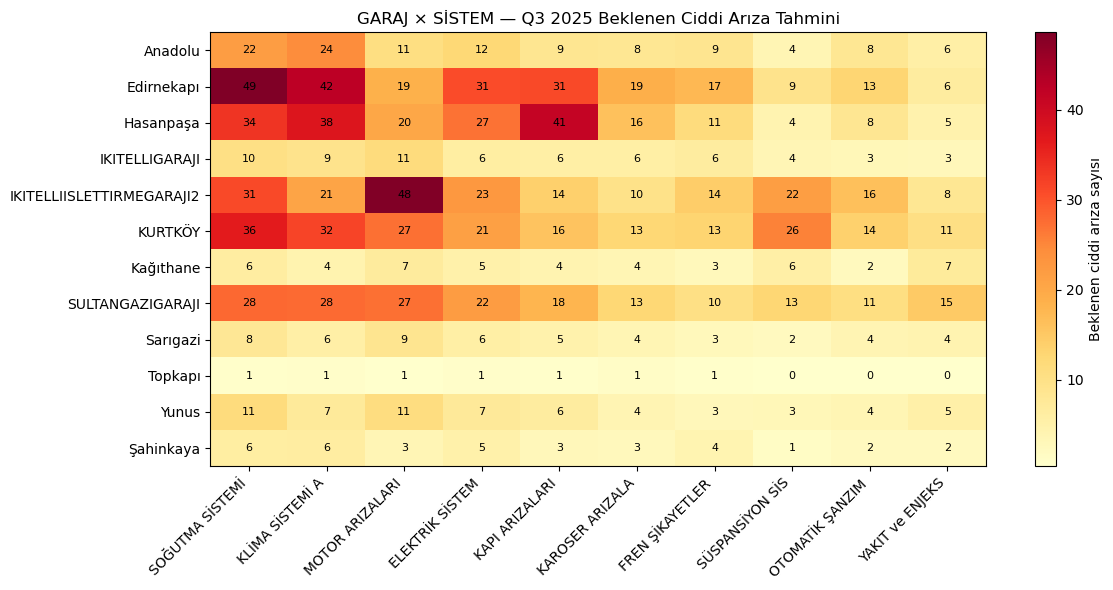

In [9]:
# Tahmin matrisini garaj bilgisi ile birleştir
# Hem ham hem duzeltilmis garaj x sistem
tahmin_merge = tahmin_matrix_duzeltilmis.copy()  # V3: duzeltilmis kullan
tahmin_merge['GARAJ'] = preds.set_index('KAPINO').loc[tahmin_merge.index, 'GARAJ']
tahmin_merge['MARKA'] = preds.set_index('KAPINO').loc[tahmin_merge.index, 'MARKA']

# Garaj başına beklenen sistem-bazlı arıza sayısı (yüksek prob × araç sayısı)
sistem_cols = [c for c in tahmin_matrix.columns if c not in ['GARAJ','MARKA']]
garaj_sistem_top = tahmin_merge.groupby('GARAJ')[sistem_cols].sum().round(2)

print('=== GARAJ × Q3 BEKLENEN CİDDİ ARIZA (top 5 sistem her garaj için) ===')
for garaj in garaj_sistem_top.index:
    top5 = garaj_sistem_top.loc[garaj].sort_values(ascending=False).head(5)
    print(f'\n{garaj}:')
    for s, v in top5.items():
        print(f'  {s:<40s} ~{v:.1f} ciddi arıza beklenti')

# Heatmap için top 10 sistem
top10_sistem = garaj_sistem_top.sum(axis=0).sort_values(ascending=False).head(10).index.tolist()
heatmap_data = garaj_sistem_top[top10_sistem]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(top10_sistem)))
ax.set_xticklabels([s[:15] for s in top10_sistem], rotation=45, ha='right')
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
for i in range(len(heatmap_data.index)):
    for j in range(len(top10_sistem)):
        ax.text(j, i, f'{heatmap_data.values[i,j]:.0f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, label='Beklenen ciddi arıza sayısı')
plt.title('GARAJ × SİSTEM — Q3 2025 Beklenen Ciddi Arıza Tahmini')
plt.tight_layout()
plt.savefig('garaj_sistem_q3_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 8. Tier × Sistem — Datathon Görsel

KRİTİK araçlar hangi sistemlerde yoğunlaşıyor?

=== TIER × SİSTEM — Ortalama Q3 Ciddi Arıza Olasılığı ===
tier                           KRİTİK  YÜKSEK    ORTA   DÜŞÜK
ARIZAUSTKODTANIM                                             
SOĞUTMA SİSTEMİ ARIZASI        0.1361  0.1019  0.0574  0.0196
KLİMA SİSTEMİ ARIZALARI        0.1183  0.0932  0.0513  0.0189
MOTOR ARIZALARI                0.1003  0.0674  0.0573  0.0209
ELEKTRİK SİSTEMİ ARIZALARI     0.0873  0.0697  0.0410  0.0153
KAPI ARIZALARI                 0.0818  0.0744  0.0316  0.0111
SÜSPANSİYON SİSTEMİ ARIZALARI  0.0565  0.0379  0.0196  0.0089
KAROSER ARIZALARI              0.0458  0.0427  0.0231  0.0121
FREN ŞİKAYETLERİ               0.0453  0.0418  0.0226  0.0099
OTOMATİK ŞANZIMAN ARIZALARI    0.0406  0.0353  0.0234  0.0084
Destek                         0.0297  0.0248  0.0135  0.0101


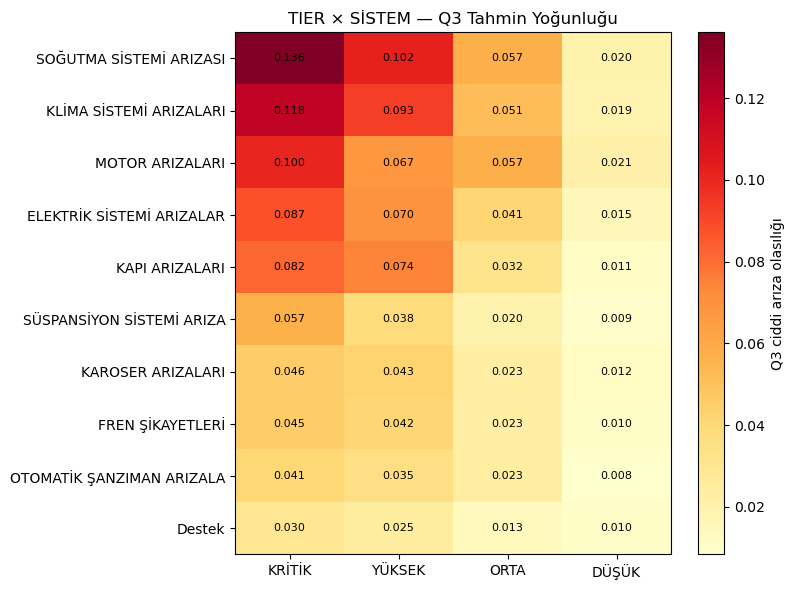

In [10]:
tahmin_merge['tier'] = preds_with_tier.set_index('KAPINO').loc[tahmin_merge.index, 'tier_duzeltilmis']  # V3: duzeltilmis tier
tier_sistem = tahmin_merge.groupby('tier')[sistem_cols].mean().round(4)

print('=== TIER × SİSTEM — Ortalama Q3 Ciddi Arıza Olasılığı ===')
tier_order = ['KRİTİK','YÜKSEK','ORTA','DÜŞÜK']
tier_sistem = tier_sistem.reindex([t for t in tier_order if t in tier_sistem.index])
top10_cols = tier_sistem.loc['KRİTİK'].sort_values(ascending=False).head(10).index.tolist()
print(tier_sistem[top10_cols].T.round(4).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(tier_sistem[top10_cols].T.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(tier_sistem.index)))
ax.set_xticklabels(tier_sistem.index)
ax.set_yticks(range(len(top10_cols)))
ax.set_yticklabels([s[:25] for s in top10_cols])
for i in range(len(top10_cols)):
    for j in range(len(tier_sistem.index)):
        v = tier_sistem[top10_cols].T.values[i,j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, label='Q3 ciddi arıza olasılığı')
plt.title('TIER × SİSTEM — Q3 Tahmin Yoğunluğu')
plt.tight_layout()
plt.savefig('tier_sistem_q3_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 9. CSV Export — arac_sistem_q3_tahmin.csv

In [11]:
# V3 EXPORT: arac_sistem_q3_tahmin.csv (tier_ham + tier_duzeltilmis + tamir carpan + top3)

# Sistem kolonlari
sistem_cols_ham = list(tahmin_matrix.columns)
sistem_cols_duz = [f'duz_{c}' for c in tahmin_matrix_duzeltilmis.columns]

# Ham tahmin export
export_ham = tahmin_matrix.reset_index().rename(columns={'index':'KAPINO'})
# Duzeltilmis tahmin (prefix "duz_")
duz_renamed = tahmin_matrix_duzeltilmis.copy()
duz_renamed.columns = [f'duz_{c}' for c in duz_renamed.columns]
export_duz = duz_renamed.reset_index().rename(columns={'index':'KAPINO'})

# Meta + tier
meta = preds_with_tier[['KAPINO','GARAJ','MARKA','MODEL','MODELYILI','ARACCINSI','YAKITTURU',
                       'ensemble_q3_ham','ensemble_q3_duzeltilmis','tier_ham','tier_duzeltilmis','manuel_kontrol_uyari','uyari_sebebi']]
export = meta.merge(export_ham, on='KAPINO', how='left').merge(export_duz, on='KAPINO', how='left')

# Top 3 sistem (ham ve duzeltilmis)
def top3_str(row, cols_prefix=''):
    if cols_prefix:
        s = pd.Series({c.replace(cols_prefix,''): row[c] for c in row.index if c.startswith(cols_prefix) and c.replace(cols_prefix,'') in tahmin_matrix.columns})
    else:
        s = pd.Series({c: row[c] for c in row.index if c in tahmin_matrix.columns})
    s = s.sort_values(ascending=False).head(3)
    return ', '.join([f'{idx} ({v*100:.1f}%)' for idx, v in s.items()])

export['top3_ham'] = export.apply(lambda r: top3_str(r), axis=1)
export['top3_duzeltilmis'] = export.apply(lambda r: top3_str(r, 'duz_'), axis=1)

out_path = 'arac_sistem_q3_tahmin_v6_5.csv'
export.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'Export: {out_path}')
print(f'  {len(export):,} arac x {len(export.columns)} kolon')
print(f'  (sistem ham + sistem duzeltilmis + meta + 2 tier + 2 top3)')

# Final ozet
print(f'\n=== V3 (TAMIR ANALIZI) FINAL OZET ===')
print(f'Tier dagilimi:')
print(f'  HAM (V6.1):         {dict(preds_with_tier["tier_ham"].value_counts())}')
print(f'  DUZELTILMIS:        {dict(preds_with_tier["tier_duzeltilmis"].value_counts())}')
print(f'\nDatathon hikayesi:')
print(f'  - {len(yukseliyor)} arac tamir analizi sonrasi YUKSELDI (kronik problemler nedeniyle)')
print(f'  - {len(duşen)} arac tamir analizi sonrasi DUSTU (tamir basarisi nedeniyle)')

Export: arac_sistem_q3_tahmin_v6_5.csv
  3,508 arac x 85 kolon
  (sistem ham + sistem duzeltilmis + meta + 2 tier + 2 top3)

=== V3 (TAMIR ANALIZI) FINAL OZET ===
Tier dagilimi:
  HAM (V6.1):         {'DÜŞÜK': np.int64(1053), 'ORTA': np.int64(1052), 'YÜKSEK': np.int64(876), 'KRİTİK': np.int64(527)}
  DUZELTILMIS:        {'DÜŞÜK': np.int64(1053), 'ORTA': np.int64(1052), 'YÜKSEK': np.int64(876), 'KRİTİK': np.int64(527)}

Datathon hikayesi:
  - 402 arac tamir analizi sonrasi YUKSELDI (kronik problemler nedeniyle)
  - 401 arac tamir analizi sonrasi DUSTU (tamir basarisi nedeniyle)
